In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

# 1. generating imbalance data (95% good, 5% Fraud)
X_data, y_data = make_classification(n_samples=1000, n_features=4, 
                                     weights=[0.95, 0.05], random_state=42)

df = pd.DataFrame(X_data, columns=['Income', 'Loan_Amount', 'Credit_Score', 'Months_Employed'])
df['Target'] = y_data # 0 = Loan Paid, 1 = Fraud

# 2.(Missing values/NaN) insertion
df.loc[10:25, 'Income'] = np.nan
df.loc[70:85, 'Credit_Score'] = np.nan



In [4]:
df.head()

,Income,Loan_Amount,Credit_Score,Months_Employed,Target
0,-1.194848,1.138331,-1.482079,1.025358,0
1,0.290131,0.317681,-0.996519,0.477009,0
2,-0.522737,-0.121434,0.765888,-0.308384,0
3,1.738138,-0.188065,-1.195371,0.302161,0
4,1.828884,-0.289261,-1.049151,0.206271,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           984 non-null    float64
 1   Loan_Amount      1000 non-null   float64
 2   Credit_Score     984 non-null    float64
 3   Months_Employed  1000 non-null   float64
 4   Target           1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [6]:
df.isnull().sum()

Income             16
Loan_Amount         0
Credit_Score       16
Months_Employed     0
Target              0
dtype: int64

### Filling null values.

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())

In [8]:
df.isnull().sum()

Income             0
Loan_Amount        0
Credit_Score       0
Months_Employed    0
Target             0
dtype: int64

In [9]:
X = df.drop('Target',axis = 1)
y = df['Target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [11]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from imblearn.pipeline import Pipeline 

In [13]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from imblearn.over_sampling import SMOTE

In [15]:
pipeline = Pipeline([('smote',SMOTE(random_state = 42)),('model', RandomForestClassifier(random_state = 42))])
print("Pipeline is ready.")

Pipeline is ready.


### Use of grid search cv for hypertuning of model for increasing accuracy or recall according to need.

In [32]:
from sklearn.model_selection import GridSearchCV

In [49]:
params_grid = {
    'model__n_estimators':[50,100,200],
    'model__class_weight': ['balanced',{0:1,1:10}]
    }

grid_search = GridSearchCV(estimator = pipeline, param_grid = params_grid,scoring = 'recall',cv = 5, n_jobs = -1)
grid_search.fit(X_train, y_train)
new_pipeline = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__class_weight': 'balanced', 'model__n_estimators': 100}


### Feature Importance & model traning with prediction. 

In [50]:
model = new_pipeline.named_steps['model']   # finding feature importance and storing them in data frame in descending order.
importance = model.feature_importances_
feature_name = X.columns
feature_df = pd.DataFrame({'Feature': feature_name,'Importance': importance})
feature_df = feature_df.sort_values(by = 'Importance', ascending = False)
print(feature_df.head())

           Feature  Importance
2     Credit_Score    0.396244
3  Months_Employed    0.276725
0           Income    0.182391
1      Loan_Amount    0.144641


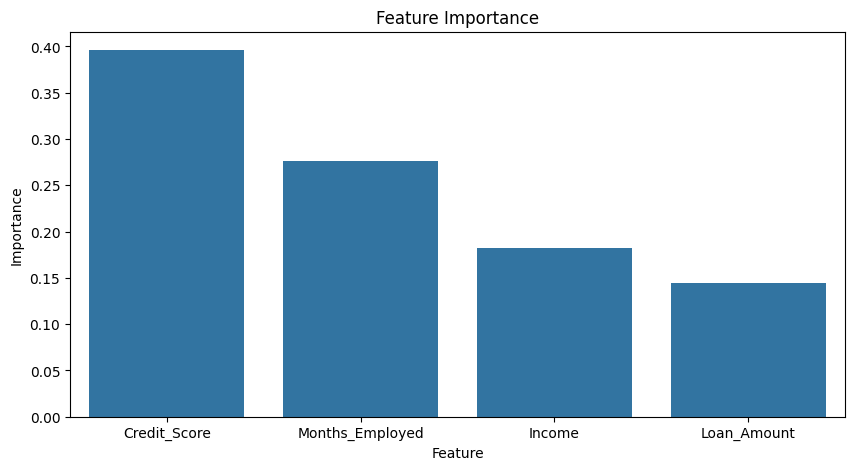

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(x = 'Feature', y = 'Importance', data = feature_df)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

In [52]:
new_pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [45]:
final_prediction = new_pipeline.predict(X_test)
final_prediction

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [53]:
accu_score = accuracy_score(y_test, finall_prediction)
print(accu_score * 100)

95.0


In [54]:
matrix = confusion_matrix(y_test, finall_prediction)
matrix

array([[182,   4],
       [  6,   8]])

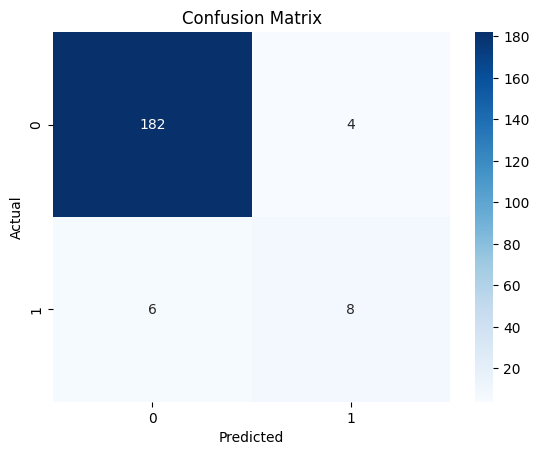

In [55]:
sns.heatmap(matrix, annot = True, fmt = 'd',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()